В этом задании вам предстоит обучить модель для прогнозироввания стоимости недвижимости и для нее интерфейс в Streamlit.

Вам нужно:
- скачать [данные](https://disk.yandex.ru/d/XDNnTb8JdvYpCA) и обучить модель прогнозирования стоимости недвижимости (модель может быть любой сложности, даже линейная регрессия на двух признаках) ЛИБО можно взять свою обученную модель из ДЗ по ML Сохраните модель в .pkl файл с помощью pickle - **2 балла**
- Реализуйте код для получения предсказания обученной моделью в .py скрипте- **1 балл**
- Реализуйте интерфейс с помощью streamlit для введения значений признаков для прогнозирования - **5 баллов**
- Реализуйте отображение результата прогнозирования в интерфейсе по нажатию кнопки, приложите в репозиторий скриншот получившегося интерфейса - **2 балла**

PS.
- Для сдачи ДЗ залейте код проекта в отдельную ветку в вашем репозитории, создайте PR и отправьте на ревью.
- Для установки python и IDE можно воспользоваться инструкциями: [Как установить Python на Windows, MacOS и Linux](https://blog.skillfactory.ru/kak-ustanovit-python-na-raznyh-os/) и [PyCharm: как её установить и использовать](https://skillbox.ru/media/code/pycharm-kak-eye-ustanovit-i-ispolzovat/)

Часть с написанием кода
---



In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
import pickle
import glob
import os
from google.colab import drive

!pip install xgboost

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = glob.glob(os.path.join('/content/drive/My Drive/HW_6', 'realty_data.csv'))
df = pd.concat(map(pd.read_csv, data), ignore_index=True)

display(df.head(3))

,product_name,period,price,postcode,address_name,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,description,source
0,"3-комнатная, 137 м²",NaN,63000000,127473.0,"2-й Щемиловский переулок, 5а",55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,Просторная квартира свободной планировки с пан...,ЦИАН
1,"Студия, 16,7 м²",NaN,3250000,108815.0,"Харлампиева, 46",55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,ВНИМАНИЕ! ОЧЕНЬ ПРИВЛЕКАТЕЛЬНОЕ ПРЕ...,Домклик
2,"3-комнатная, 76 м²",NaN,16004680,NaN,"ЖК Прокшино, 8 к4",55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,"Apт.1684018. 0,01% - гибкая ипотека! Воспользу...",Яндекс.Недвижимость


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98822 entries, 0 to 98821
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  98822 non-null  object 
 1   period        0 non-null      float64
 2   price         98822 non-null  int64  
 3   postcode      93675 non-null  float64
 4   address_name  98821 non-null  object 
 5   lat           98822 non-null  float64
 6   lon           98822 non-null  float64
 7   object_type   98822 non-null  object 
 8   total_square  98822 non-null  float64
 9   rooms         94840 non-null  float64
 10  floor         98822 non-null  float64
 11  city          91928 non-null  object 
 12  settlement    6894 non-null   object 
 13  district      75111 non-null  object 
 14  area          19498 non-null  object 
 15  description   98573 non-null  object 
 16  source        98822 non-null  object 
dtypes: float64(7), int64(1), object(9)
memory usage: 12.8+ MB


In [ ]:
df.describe()

,period,price,postcode,lat,lon,total_square,rooms,floor
count,0.0,9.882200e+04,93675.000000,98822.000000,98822.000000,98822.000000,94840.000000,98822.000000
mean,NaN,2.512122e+07,124503.585119,55.742691,37.586404,66.092176,2.197427,9.905274
std,NaN,3.607234e+07,11956.742109,0.107044,0.169843,48.816204,1.038628,8.219180
min,NaN,1.900000e+06,101000.000000,55.468426,37.136489,8.000000,1.000000,1.000000
25%,NaN,1.050000e+07,115516.000000,55.673101,37.471611,40.100000,1.000000,4.000000
50%,NaN,1.516713e+07,123154.000000,55.745474,37.569365,56.400000,2.000000,8.000000
75%,NaN,2.500000e+07,140003.000000,55.817697,37.689568,75.700000,3.000000,14.000000
max,NaN,1.155219e+09,143989.000000,56.028824,38.122467,2070.000000,15.000000,66.000000


Удалим категориальные признаки, которые либо пустые, либо можно создать простейшую модель и без

In [ ]:
df = df.drop(columns=['product_name', 'period', 'address_name', 'object_type','city', 'settlement', 'district', 'area', 'description', 'source', 'postcode', 'lat', 'lon'])

In [ ]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94840 entries, 0 to 98821
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         94840 non-null  int64  
 1   total_square  94840 non-null  float64
 2   rooms         94840 non-null  float64
 3   floor         94840 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 3.6 MB


In [ ]:
df.head()

,price,total_square,rooms,floor
0,63000000,137.0,3.0,6.0
2,16004680,76.0,3.0,6.0
3,7841776,24.0,1.0,10.0
4,120000000,126.0,3.0,16.0
5,13300000,74.0,3.0,14.0


Нужно предсказывать цену, поэтому выделим её в качестве целевой переменной и  разделим выборки на train и test

In [ ]:
x = df.drop(columns='price')
y = df['price']

Построим модель  XGBRegressor

In [ ]:
remodel = XGBRegressor(n_estimators=250, learning_rate=0.05, random_state=25)
remodel.fit(x, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=250, n_jobs=None,
             num_parallel_tree=None, random_state=25, ...)

In [ ]:
with open("realty_data.pkl", "wb") as a:
    pickle.dump(remodel, a)

In [ ]:
%%writefile predict.py

# @title Inference form {display-mode: "form"}
import pickle

def re_load():
    with open("realty_data.pkl", "rb") as a:
        remodel = pickle.load(a)  # Загружаем модель
    return remodel

def predprice(features):
    remodel = re_load()  # Загружаем модель через re_load
    price = remodel.predict([features])
    return round(price[0], 0)  # округляем до целого числа


Writing predict.py


Попробуем вывести предсказания с различными параметрами

In [ ]:
from predict import predprice

print('Price',predprice([30, 1, 1]))
print('Price',predprice([50, 3, 6]))
print('Price',predprice([40, 2, 4]))
 # Пример использования

Price 7650764.0
Price 13721776.0
Price 11758317.0


Streamlit
---



Запустим Streamlit и добавим библиотеки

In [ ]:
!pip install -q streamlit
import streamlit as st
import urllib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 4.3 MB/s eta 0:00:00


Получим IP

In [ ]:
print("Password/Enpoint IP for localtunnel is:",urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

Password/Enpoint IP for localtunnel is: 34.23.216.30


Создадим Streamlit app и зададим параметры каждой из ячеек

In [ ]:
%%writefile app.py
import streamlit as st
from predict import predprice

st.title("Прогнозирование стоимости недвижимости с XGBoost")

total_square = st.number_input("Площадь (кв.м)", min_value=10.0, step=0.1)
rooms = st.number_input("Количество комнат", min_value=1, step=1)
floor = st.number_input("Этаж", min_value=1, step=1)

if st.button("Предсказать стоимость"):
    features = [total_square, rooms, floor]
    price = predprice(features)
    st.write(f"Предполагаемая стоимость: {price:.0f} руб.")

Writing app.py


Устанавливаем библиотеку для локального тунеля

In [ ]:
!npm install localtunnel


added 22 packages, and audited 23 packages in 4s

3 packages are looking for funding
  run `npm fund` for details

2 moderate severity vulnerabilities

To address all issues, run:
  npm audit fix

Run `npm audit` for details.


In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

your url is: https://tricky-walls-notice.loca.lt
^C


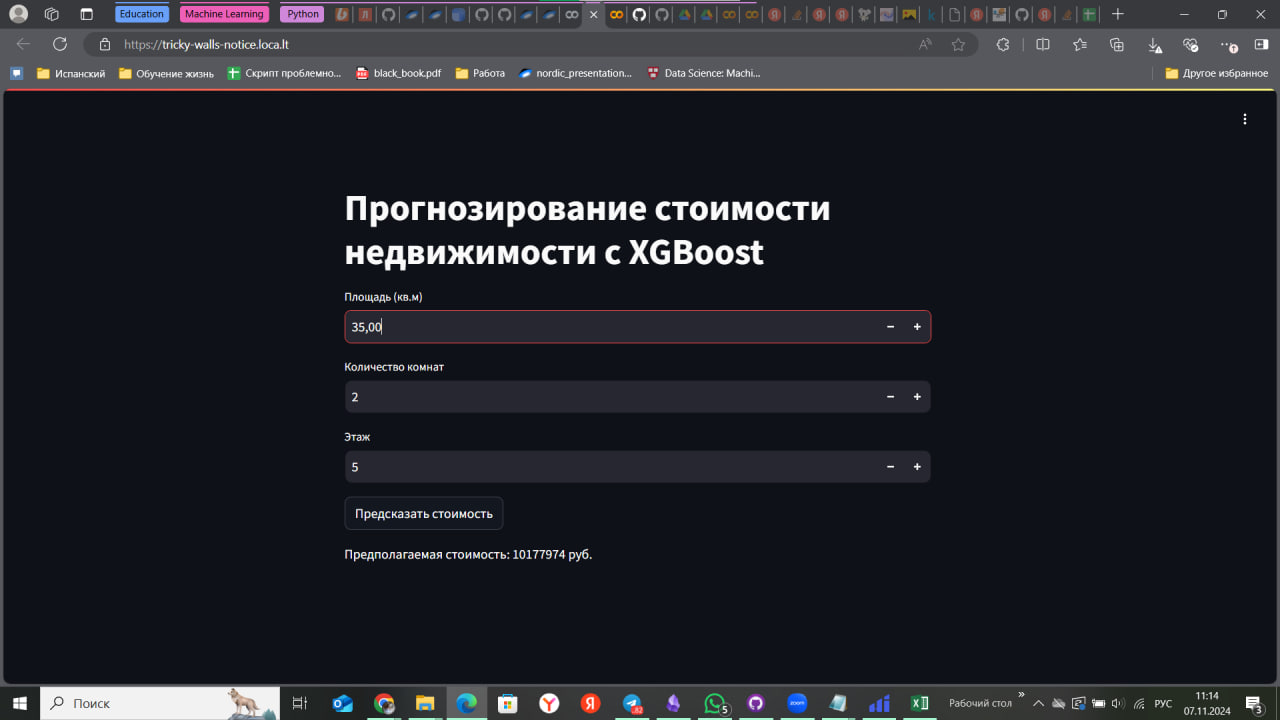